In [24]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import re
import uuid
import pandas as pd
import numpy as np

from tqdm import tqdm

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [25]:
# ============================================================
# CELL 2 — LOAD FEATURE ENGINEERED DATASET
# ============================================================

DATASET_PATH = "../parquet_exports/feature_engineered_dataset.parquet"

df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

df.head()

DATASET LOADED
Rows    : 230,088
Columns : 21


,document_id,ticket_pk,retrieval_text_clean,metadata_json,source_system_encoded,similarity_method_encoded,priority_encoded,urgency_encoded,impact_encoded,text_word_count,text_char_count,avg_word_length,unique_word_ratio,uppercase_ratio,digit_ratio,special_char_ratio,repetition_ratio,text_complexity_score,retrieval_quality_score,corpus_quality_score,similarity_confidence
0,doc_0,2013_2,prio_high urg_critical impact_medium ticket_un...,"{""ticket_pk"": ""2013_2"", ""source_system"": ""GLPI...",0,1,4.0,5.0,3.0,6,97,15.333333,1.0,0.0,0.0,0.072165,0.0,6.545333,0.516667,0.3,0.25
1,doc_1,2013_3,prio_medium urg_medium impact_medium ticket_un...,"{""ticket_pk"": ""2013_3"", ""source_system"": ""GLPI...",0,1,3.0,3.0,3.0,6,97,15.333333,1.0,0.0,0.0,0.072165,0.0,6.545333,0.516667,0.3,0.25
2,doc_2,2013_4,prio_medium urg_medium impact_medium ticket_un...,"{""ticket_pk"": ""2013_4"", ""source_system"": ""GLPI...",0,1,3.0,3.0,3.0,7,117,15.857143,1.0,0.0,0.0,0.076923,0.0,6.756857,0.650000,0.5,0.45
3,doc_3,2013_5,prio_critical urg_critical impact_high ticket_...,"{""ticket_pk"": ""2013_5"", ""source_system"": ""GLPI...",0,1,5.0,5.0,4.0,6,100,15.833333,1.0,0.0,0.0,0.080000,0.0,6.745333,0.516667,0.3,0.25
4,doc_4,2013_6,prio_medium urg_medium impact_medium ticket_un...,"{""ticket_pk"": ""2013_6"", ""source_system"": ""GLPI...",0,1,3.0,3.0,3.0,6,93,14.666667,1.0,0.0,0.0,0.075269,0.0,6.278667,0.516667,0.3,0.25


In [26]:
# ============================================================
# CELL 3 — VALIDATE RETRIEVAL TEXT
# ============================================================

TEXT_COLUMN = "retrieval_text_clean"

empty_rows = (
    df[TEXT_COLUMN]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

duplicate_texts = (
    df[TEXT_COLUMN]
    .duplicated()
    .sum()
)

print("=" * 60)
print("RETRIEVAL TEXT VALIDATION")
print("=" * 60)

print(f"Empty texts       : {empty_rows:,}")
print(f"Duplicate texts   : {duplicate_texts:,}")

RETRIEVAL TEXT VALIDATION
Empty texts       : 0
Duplicate texts   : 201,413


In [27]:
# ============================================================
# CELL 4 — REMOVE INVALID ROWS
# ============================================================

before_rows = len(df)

# Remove empty texts only
df = df[
    df[TEXT_COLUMN]
    .fillna("")
    .str.strip()
    != ""
].copy()

# Remove duplicate DOCUMENT IDs only
if "document_id" in df.columns:

    df = (
        df
        .drop_duplicates(subset=["document_id"])
        .reset_index(drop=True)
    )

removed_rows = before_rows - len(df)

print("=" * 60)
print("INVALID ROW FILTER")
print("=" * 60)

print(f"Removed rows : {removed_rows:,}")
print(f"Remaining    : {len(df):,}")

INVALID ROW FILTER
Removed rows : 0
Remaining    : 230,088


In [28]:
# ============================================================
# CELL 5 — SIMPLE TOKEN ESTIMATION
# ============================================================

def estimate_tokens(text: str) -> int:
    """
    Rough token estimation.
    Approximation:
    1 token ≈ 0.75 words
    """

    words = str(text).split()

    return int(len(words) / 0.75)


df["estimated_tokens"] = (
    df[TEXT_COLUMN]
    .apply(estimate_tokens)
)

print("estimated_tokens created.")

df["estimated_tokens"].describe()

estimated_tokens created.


count    230088.000000
mean         35.186928
std          22.247166
min           6.000000
25%          26.000000
50%          29.000000
75%          34.000000
max         268.000000
Name: estimated_tokens, dtype: float64

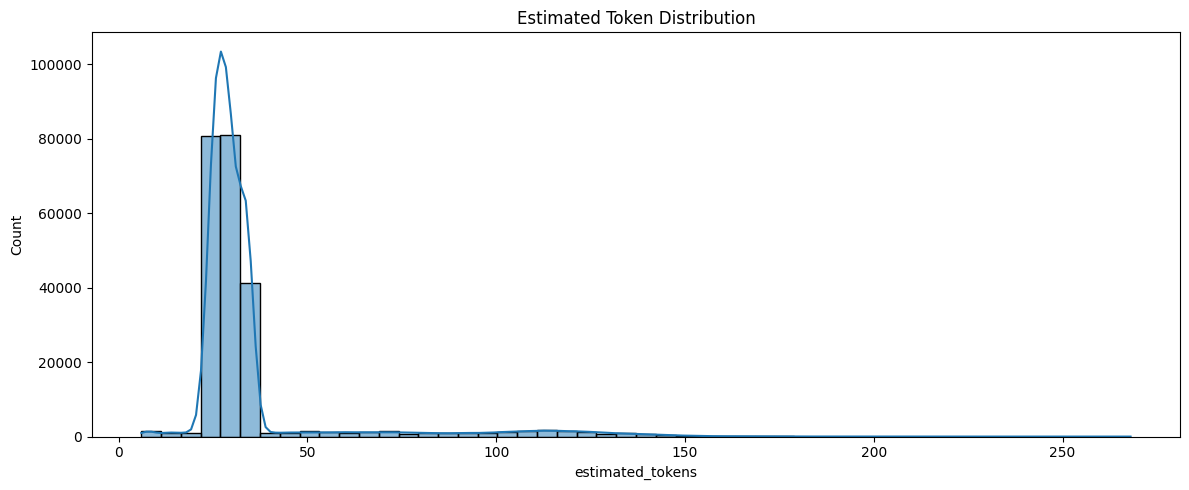

In [29]:
# ============================================================
# CELL 6 — TOKEN DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

sns.histplot(
    df["estimated_tokens"],
    bins=50,
    kde=True
)

plt.title("Estimated Token Distribution")

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# CELL 7 — CHUNKING CONFIG
# ============================================================

CHUNK_SIZE = 256
CHUNK_OVERLAP = 50

print("=" * 60)
print("CHUNKING CONFIG")
print("=" * 60)

print(f"Chunk Size     : {CHUNK_SIZE}")
print(f"Chunk Overlap  : {CHUNK_OVERLAP}")

CHUNKING CONFIG
Chunk Size     : 256
Chunk Overlap  : 50


In [31]:
# ============================================================
# CELL 8 — TEXT CHUNKING FUNCTION
# ============================================================

def chunk_text(
    text: str,
    chunk_size: int = 256,
    overlap: int = 50
):

    words = str(text).split()

    chunks = []

    start = 0

    while start < len(words):

        end = start + chunk_size

        chunk = words[start:end]

        chunks.append(" ".join(chunk))

        start += chunk_size - overlap

    return chunks


print("chunk_text function created.")

chunk_text function created.


In [32]:
# ============================================================
# CELL 9 — GENERATE DOCUMENT CHUNKS
# ============================================================

tqdm.pandas(desc="Chunking documents")

df["chunks"] = (
    df[TEXT_COLUMN]
    .progress_apply(
        lambda x: chunk_text(
            x,
            chunk_size=CHUNK_SIZE,
            overlap=CHUNK_OVERLAP
        )
    )
)

print("Chunks generated successfully.")

df[
    [
        "document_id",
        "chunks"
    ]
].head()

Chunking documents: 100%|██████████| 230088/230088 [00:01<00:00, 116602.56it/s]

Chunks generated successfully.


,document_id,chunks
0,doc_0,[prio_high urg_critical impact_medium ticket_u...
1,doc_1,[prio_medium urg_medium impact_medium ticket_u...
2,doc_2,[prio_medium urg_medium impact_medium ticket_u...
3,doc_3,[prio_critical urg_critical impact_high ticket...
4,doc_4,[prio_medium urg_medium impact_medium ticket_u...


In [33]:
# ============================================================
# CELL 10 — FLATTEN CHUNKS
# ============================================================

chunk_rows = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    for chunk_index, chunk in enumerate(row["chunks"]):

        chunk_rows.append({
            "chunk_id": f"{row['document_id']}_chunk_{chunk_index}",

            "document_id": row["document_id"],

            "ticket_pk": row.get("ticket_pk"),

            "chunk_index": chunk_index,

            "chunk_text": chunk,

            "chunk_word_count": len(chunk.split()),

            "chunk_token_estimate": estimate_tokens(chunk),

            "metadata_json": row.get("metadata_json"),

            "priority_encoded": row.get("priority_encoded"),

            "urgency_encoded": row.get("urgency_encoded"),

            "impact_encoded": row.get("impact_encoded"),

            "retrieval_quality_score": row.get("retrieval_quality_score")
        })

chunk_df = pd.DataFrame(chunk_rows)

print("=" * 60)
print("CHUNK DATAFRAME CREATED")
print("=" * 60)

print(f"Total Chunks : {len(chunk_df):,}")

chunk_df.head()


100%|██████████| 230088/230088 [00:33<00:00, 6899.53it/s]


CHUNK DATAFRAME CREATED
Total Chunks : 230,088


,chunk_id,document_id,ticket_pk,chunk_index,chunk_text,chunk_word_count,chunk_token_estimate,metadata_json,priority_encoded,urgency_encoded,impact_encoded,retrieval_quality_score
0,doc_0_chunk_0,doc_0,2013_2,0,prio_high urg_critical impact_medium ticket_un...,6,8,"{""ticket_pk"": ""2013_2"", ""source_system"": ""GLPI...",4.0,5.0,3.0,0.516667
1,doc_1_chunk_0,doc_1,2013_3,0,prio_medium urg_medium impact_medium ticket_un...,6,8,"{""ticket_pk"": ""2013_3"", ""source_system"": ""GLPI...",3.0,3.0,3.0,0.516667
2,doc_2_chunk_0,doc_2,2013_4,0,prio_medium urg_medium impact_medium ticket_un...,7,9,"{""ticket_pk"": ""2013_4"", ""source_system"": ""GLPI...",3.0,3.0,3.0,0.650000
3,doc_3_chunk_0,doc_3,2013_5,0,prio_critical urg_critical impact_high ticket_...,6,8,"{""ticket_pk"": ""2013_5"", ""source_system"": ""GLPI...",5.0,5.0,4.0,0.516667
4,doc_4_chunk_0,doc_4,2013_6,0,prio_medium urg_medium impact_medium ticket_un...,6,8,"{""ticket_pk"": ""2013_6"", ""source_system"": ""GLPI...",3.0,3.0,3.0,0.516667


In [34]:
# ============================================================
# CELL 11 — CHUNK STATISTICS
# ============================================================

print("=" * 60)
print("CHUNK STATISTICS")
print("=" * 60)

print(f"Average Chunk Word Count  : {chunk_df['chunk_word_count'].mean():.2f}")

print(f"Average Token Estimate    : {chunk_df['chunk_token_estimate'].mean():.2f}")

print(f"Max Token Estimate        : {chunk_df['chunk_token_estimate'].max()}")

print(f"Min Token Estimate        : {chunk_df['chunk_token_estimate'].min()}")

CHUNK STATISTICS
Average Chunk Word Count  : 26.71
Average Token Estimate    : 35.19
Max Token Estimate        : 268
Min Token Estimate        : 6


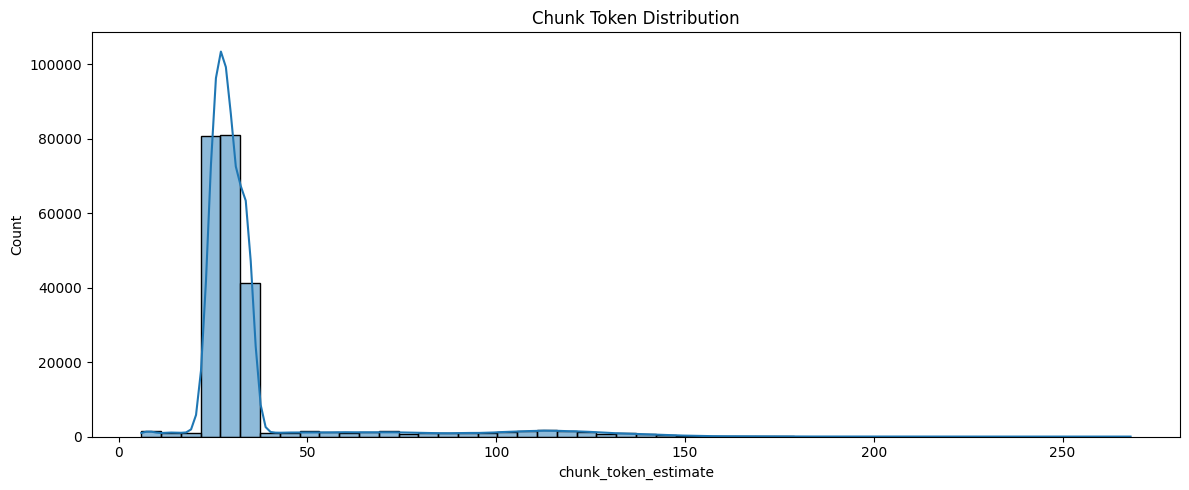

In [35]:
# ============================================================
# CELL 12 — CHUNK TOKEN DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 5))

sns.histplot(
    chunk_df["chunk_token_estimate"],
    bins=50,
    kde=True
)

plt.title("Chunk Token Distribution")

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# CELL 13 — BM25 TOKENIZATION PREPARATION
# ============================================================

def bm25_tokenizer(text: str):

    text = str(text)

    text = text.lower()

    tokens = re.findall(r"\b\w+\b", text)

    return tokens


chunk_df["bm25_tokens"] = (
    chunk_df["chunk_text"]
    .apply(bm25_tokenizer)
)

print("BM25 tokenization completed.")

chunk_df[
    [
        "chunk_text",
        "bm25_tokens"
    ]
].head()

BM25 tokenization completed.


,chunk_text,bm25_tokens
0,prio_high urg_critical impact_medium ticket_un...,"[prio_high, urg_critical, impact_medium, ticke..."
1,prio_medium urg_medium impact_medium ticket_un...,"[prio_medium, urg_medium, impact_medium, ticke..."
2,prio_medium urg_medium impact_medium ticket_un...,"[prio_medium, urg_medium, impact_medium, ticke..."
3,prio_critical urg_critical impact_high ticket_...,"[prio_critical, urg_critical, impact_high, tic..."
4,prio_medium urg_medium impact_medium ticket_un...,"[prio_medium, urg_medium, impact_medium, ticke..."


In [37]:
# ============================================================
# CELL 14 — FILTER BAD CHUNKS
# ============================================================

MIN_CHUNK_WORDS = 5

before_chunks = len(chunk_df)

chunk_df = chunk_df[
    chunk_df["chunk_word_count"] >= MIN_CHUNK_WORDS
].copy()

removed_chunks = before_chunks - len(chunk_df)

print("=" * 60)
print("BAD CHUNK FILTER")
print("=" * 60)

print(f"Removed chunks : {removed_chunks:,}")
print(f"Remaining      : {len(chunk_df):,}")

BAD CHUNK FILTER
Removed chunks : 0
Remaining      : 230,088


In [38]:
# ============================================================
# CELL 15 — RETRIEVAL METADATA VALIDATION
# ============================================================

missing_metadata = (
    chunk_df["metadata_json"]
    .isna()
    .sum()
)

print("=" * 60)
print("METADATA VALIDATION")
print("=" * 60)

print(f"Missing metadata rows : {missing_metadata:,}")

METADATA VALIDATION
Missing metadata rows : 0


In [39]:
# ============================================================
# CELL 16 — FINAL RETRIEVAL DATASET
# ============================================================

FINAL_COLUMNS = [
    "chunk_id",
    "document_id",
    "ticket_pk",
    "chunk_index",
    "chunk_text",
    "chunk_word_count",
    "chunk_token_estimate",
    "bm25_tokens",
    "metadata_json",
    "priority_encoded",
    "urgency_encoded",
    "impact_encoded",
    "retrieval_quality_score"
]

retrieval_ready_df = (
    chunk_df[FINAL_COLUMNS]
    .reset_index(drop=True)
)

print("=" * 60)
print("FINAL RETRIEVAL DATASET")
print("=" * 60)

print(f"Rows    : {len(retrieval_ready_df):,}")
print(f"Columns : {retrieval_ready_df.shape[1]}")

retrieval_ready_df.head()

FINAL RETRIEVAL DATASET
Rows    : 230,088
Columns : 13


,chunk_id,document_id,ticket_pk,chunk_index,chunk_text,chunk_word_count,chunk_token_estimate,bm25_tokens,metadata_json,priority_encoded,urgency_encoded,impact_encoded,retrieval_quality_score
0,doc_0_chunk_0,doc_0,2013_2,0,prio_high urg_critical impact_medium ticket_un...,6,8,"[prio_high, urg_critical, impact_medium, ticke...","{""ticket_pk"": ""2013_2"", ""source_system"": ""GLPI...",4.0,5.0,3.0,0.516667
1,doc_1_chunk_0,doc_1,2013_3,0,prio_medium urg_medium impact_medium ticket_un...,6,8,"[prio_medium, urg_medium, impact_medium, ticke...","{""ticket_pk"": ""2013_3"", ""source_system"": ""GLPI...",3.0,3.0,3.0,0.516667
2,doc_2_chunk_0,doc_2,2013_4,0,prio_medium urg_medium impact_medium ticket_un...,7,9,"[prio_medium, urg_medium, impact_medium, ticke...","{""ticket_pk"": ""2013_4"", ""source_system"": ""GLPI...",3.0,3.0,3.0,0.650000
3,doc_3_chunk_0,doc_3,2013_5,0,prio_critical urg_critical impact_high ticket_...,6,8,"[prio_critical, urg_critical, impact_high, tic...","{""ticket_pk"": ""2013_5"", ""source_system"": ""GLPI...",5.0,5.0,4.0,0.516667
4,doc_4_chunk_0,doc_4,2013_6,0,prio_medium urg_medium impact_medium ticket_un...,6,8,"[prio_medium, urg_medium, impact_medium, ticke...","{""ticket_pk"": ""2013_6"", ""source_system"": ""GLPI...",3.0,3.0,3.0,0.516667


In [40]:
# ============================================================
# CELL 17 — EXPORT RETRIEVAL DATASET
# ============================================================

EXPORT_PATH = "../parquet_exports/retrieval_ready_dataset.parquet"

retrieval_ready_df.to_parquet(
    EXPORT_PATH,
    index=False
)

print("=" * 60)
print("RETRIEVAL DATASET EXPORTED")
print("=" * 60)

print(f"Export path:\n{EXPORT_PATH}")

RETRIEVAL DATASET EXPORTED
Export path:
../parquet_exports/retrieval_ready_dataset.parquet


In [41]:
# ============================================================
# CELL 18 — EXPORT BM25 CORPUS
# ============================================================

BM25_EXPORT_PATH = "../parquet_exports/bm25_corpus.pkl"

retrieval_ready_df["bm25_tokens"].to_pickle(
    BM25_EXPORT_PATH
)

print(f"BM25 corpus exported:\n{BM25_EXPORT_PATH}")

BM25 corpus exported:
../parquet_exports/bm25_corpus.pkl


In [42]:
# ============================================================
# CELL 19 — EXPORT SAMPLE
# ============================================================

SAMPLE_EXPORT = "../evaluation/retrieval_ready_sample.csv"

retrieval_ready_df.head(100).to_csv(
    SAMPLE_EXPORT,
    index=False
)

print(f"Sample exported:\n{SAMPLE_EXPORT}")

Sample exported:
../evaluation/retrieval_ready_sample.csv


In [43]:
# ============================================================
# CELL 20 — FINAL RETRIEVAL REPORT
# ============================================================

print("=" * 60)
print("FINAL RETRIEVAL REPORT")
print("=" * 60)

print(f"Documents                  : {df['document_id'].nunique():,}")

print(f"Total Chunks               : {len(retrieval_ready_df):,}")

print(f"Average Chunks per Doc     : {len(retrieval_ready_df) / df['document_id'].nunique():.2f}")

print(f"Average Chunk Tokens       : {retrieval_ready_df['chunk_token_estimate'].mean():.2f}")

print(f"Max Chunk Tokens           : {retrieval_ready_df['chunk_token_estimate'].max()}")

print(f"Min Chunk Tokens           : {retrieval_ready_df['chunk_token_estimate'].min()}")

print(f"Average Retrieval Quality  : {retrieval_ready_df['retrieval_quality_score'].mean():.4f}")

FINAL RETRIEVAL REPORT
Documents                  : 230,088
Total Chunks               : 230,088
Average Chunks per Doc     : 1.00
Average Chunk Tokens       : 35.19
Max Chunk Tokens           : 268
Min Chunk Tokens           : 6
Average Retrieval Quality  : 0.8095
